Verify the Project Data Set

First, verify that the notebook executes correctly before connecting to Hugging Face.

In [7]:
import sys
import pandas as pd
import numpy as np
import sklearn

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:12:50) [MSC v.1942 64 bit (AMD64)]
Pandas: 2.2.3
NumPy: 2.2.5
Scikit-learn: 1.6.1


## 1. Load the Banking Intent Dataset

The project uses the Cleanlab Banking Intent Classification dataset.
The objective is to classify customer messages into banking intents that can
later be used by BankAssist Triage to route customer requests.

In [8]:
from datasets import load_dataset

dataset = load_dataset("Cleanlab/banking-intent-classification")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})


In [9]:
# Inspect the dataset
print(dataset)

# Convert the training data to a pandas DataFrame
df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head(10)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})
Dataset shape: (1000, 2)

Columns: ['text', 'label']


,text,label
0,i accidentally made a payment to a wrong accou...,cancel_transfer
1,"i no longer want to transfer funds, can we can...",cancel_transfer
2,"cancel my transfer, please.",cancel_transfer
3,i want to revert this mornings transaction.,cancel_transfer
4,i just realised i made the wrong payment yeste...,cancel_transfer
5,i want to cancel a transaction from this morning.,cancel_transfer
6,i need to stop a transaction that i made.,cancel_transfer
7,can i stop a transaction?,cancel_transfer
8,how can i cancel a transfer i made,cancel_transfer
9,i'm really upset because i made a typo during ...,cancel_transfer


Step 1 — Data-quality check

Add a new Code cell below this one and paste:

In [4]:
# ==========================================
# DATA QUALITY CHECK
# ==========================================

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\n--- Missing values ---")
print(df.isnull().sum())

print("\n--- Duplicate rows ---")
print("Exact duplicates:", df.duplicated().sum())

print("\n--- Duplicate texts ---")
print("Repeated customer messages:", df["text"].duplicated().sum())

print("\n--- Number of intent classes ---")
print("Unique labels:", df["label"].nunique())

print("\n--- Class distribution ---")
print(df["label"].value_counts())

print("\n--- Text length statistics ---")
df["text_length"] = df["text"].str.len()
print(df["text_length"].describe())

Number of rows: 1000
Number of columns: 2

--- Missing values ---
text     0
label    0
dtype: int64

--- Duplicate rows ---
Exact duplicates: 0

--- Duplicate texts ---
Repeated customer messages: 0

--- Number of intent classes ---
Unique labels: 10

--- Class distribution ---
label
card_payment_fee_charged          138
beneficiary_not_allowed           111
cancel_transfer                   109
visa_or_mastercard                 98
card_about_to_expire               98
supported_cards_and_currencies     95
apple_pay_or_google_pay            93
getting_spare_card                 90
change_pin                         88
lost_or_stolen_phone               80
Name: count, dtype: int64

--- Text length statistics ---
count    1000.000000
mean       55.689000
std        30.408798
min        13.000000
25%        36.750000
50%        47.000000
75%        62.000000
max       213.000000
Name: text_length, dtype: float64


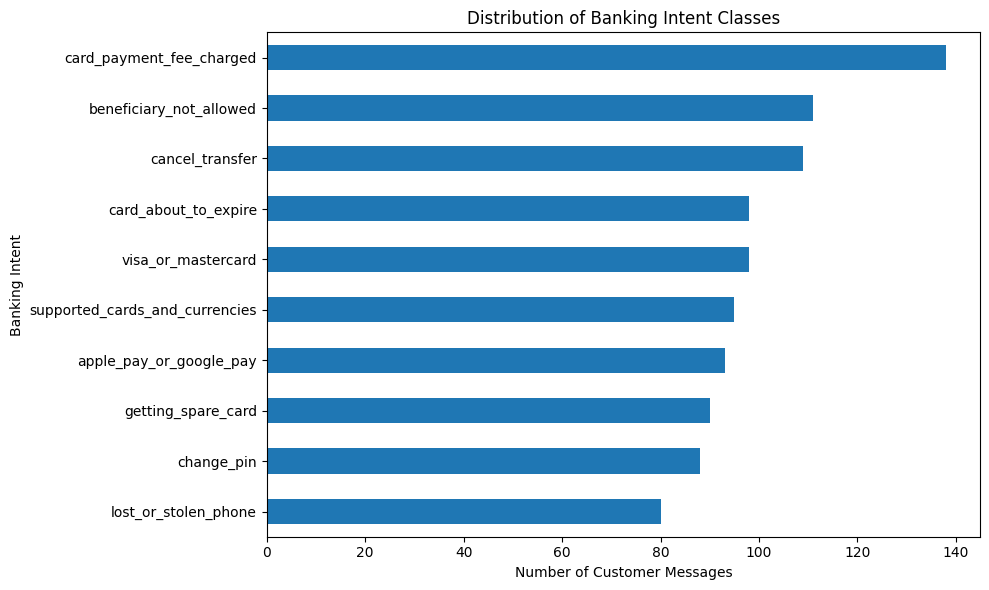

Smallest class: lost_or_stolen_phone - 80
Largest class: card_payment_fee_charged - 138
Imbalance ratio: 1.72


In [5]:
import matplotlib.pyplot as plt

# Count examples per banking intent
class_counts = df["label"].value_counts().sort_values()

# Create chart
plt.figure(figsize=(10, 6))
class_counts.plot(kind="barh")

plt.title("Distribution of Banking Intent Classes")
plt.xlabel("Number of Customer Messages")
plt.ylabel("Banking Intent")
plt.tight_layout()
plt.show()

# Summary
print("Smallest class:", class_counts.index[0], "-", class_counts.iloc[0])
print("Largest class:", class_counts.index[-1], "-", class_counts.iloc[-1])
print("Imbalance ratio:", round(class_counts.iloc[-1] / class_counts.iloc[0], 2))

An imbalance ratio of 1.72 means the largest class has about 72% more examples than the smallest. That's a moderate difference, but not an extreme imbalance. I would not rebalance or oversample the data at this stage. Instead, we document it and later use appropriate multiclass metrics such as macro F1 alongside accuracy.

Next: investigate ambiguity between intents

This is especially important for your Cleanlab dataset because the ML model may struggle when different banking intents use similar language.

In [6]:
# Show 5 example messages from each intent

for label in sorted(df["label"].unique()):
    print("\n" + "=" * 70)
    print("INTENT:", label)
    print("=" * 70)

    examples = df[df["label"] == label]["text"].head(5)

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")


INTENT: apple_pay_or_google_pay
1. google play top up help?
2. what services can i use to top up?
3. top up for my american express card is not working
4. can i use american express with apple pay? why does it make my top up not work?
5. how do i get top up to work for my card

INTENT: beneficiary_not_allowed
1. why did my transfer to a beneficiary fail?
2. why is my beneficiary being denies?
3. why am i not allowed to add a certain beneficiary?
4. what are then rules on beneficiaries?
5. my transfer to a beneficiary did not go through.  why?

INTENT: cancel_transfer
1. i accidentally made a payment to a wrong account. what should i do?
2. i no longer want to transfer funds, can we cancel that transaction?
3. cancel my transfer, please.
4. i want to revert this mornings transaction.
5. i just realised i made the wrong payment yesterday. can you please change it to the right account? it's my rent payment and really really needs to be in the right account by tomorrow

INTENT: card_about

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Represent each intent by the combined text of its examples.
intent_texts = df.groupby("label")["text"].agg(" ".join)
vectorizer = TfidfVectorizer(stop_words="english")
intent_vectors = vectorizer.fit_transform(intent_texts)

similarity_df = pd.DataFrame(
    cosine_similarity(intent_vectors),
    index=intent_texts.index,
    columns=intent_texts.index,
)

pairs = []

labels = similarity_df.index

for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        pairs.append({
            "intent_1": labels[i],
            "intent_2": labels[j],
            "similarity": similarity_df.iloc[i, j]
        })

similar_pairs = pd.DataFrame(pairs).sort_values(
    "similarity",
    ascending=False
)

similar_pairs.head(10)

,intent_1,intent_2,similarity
26,card_about_to_expire,getting_spare_card,0.369281
40,getting_spare_card,supported_cards_and_currencies,0.335182
9,beneficiary_not_allowed,cancel_transfer,0.333517
31,card_payment_fee_charged,getting_spare_card,0.299687
24,card_about_to_expire,card_payment_fee_charged,0.266272
28,card_about_to_expire,supported_cards_and_currencies,0.176372
33,card_payment_fee_charged,supported_cards_and_currencies,0.130486
7,apple_pay_or_google_pay,supported_cards_and_currencies,0.120981
15,beneficiary_not_allowed,supported_cards_and_currencies,0.104516
29,card_about_to_expire,visa_or_mastercard,0.103697


## 2. Prepare Data for Machine Learning

The dataset will be divided into training and test sets.

A stratified split is used to preserve the distribution of banking intents
in both datasets and reduce the risk of evaluating the model on an
unrepresentative sample.

In [9]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Total:", len(X_train) + len(X_test))

Training samples: 800
Test samples: 200
Total: 1000


## 3. Baseline Machine Learning Model

A baseline text classification model is created using TF-IDF for text
vectorization and Logistic Regression for multiclass classification.

The baseline provides a reference point against which more advanced
models can later be compared.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


c:\Users\lilia\OneDrive\Desktop\PBS\Machine Learning\bankassist-triage\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## 4. Baseline Model Evaluation

The trained model is evaluated on the test dataset, which contains
customer messages that were not used during training.

Accuracy and classification metrics are used to evaluate how well the
model generalizes to unseen customer requests.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Predict the intents of the unseen test messages
y_pred = baseline_model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 91.00%

Classification Report:
                                precision    recall  f1-score   support

       apple_pay_or_google_pay       0.94      0.84      0.89        19
       beneficiary_not_allowed       0.83      0.91      0.87        22
               cancel_transfer       1.00      0.95      0.98        22
          card_about_to_expire       0.84      0.84      0.84        19
      card_payment_fee_charged       0.82      1.00      0.90        28
                    change_pin       0.89      0.94      0.92        18
            getting_spare_card       1.00      0.94      0.97        18
          lost_or_stolen_phone       1.00      0.81      0.90        16
supported_cards_and_currencies       0.89      0.89      0.89        19
            visa_or_mastercard       1.00      0.89      0.94        19

                      accuracy                           0.91       200
                     macro avg       0.92      0.90      0.91       200
                

## 5. Confusion Matrix and Error Analysis

A confusion matrix is used to identify which banking intents are most
frequently confused by the baseline classifier.

This analysis helps determine whether errors are related to overlapping
language, ambiguous customer requests, or limitations of the model.

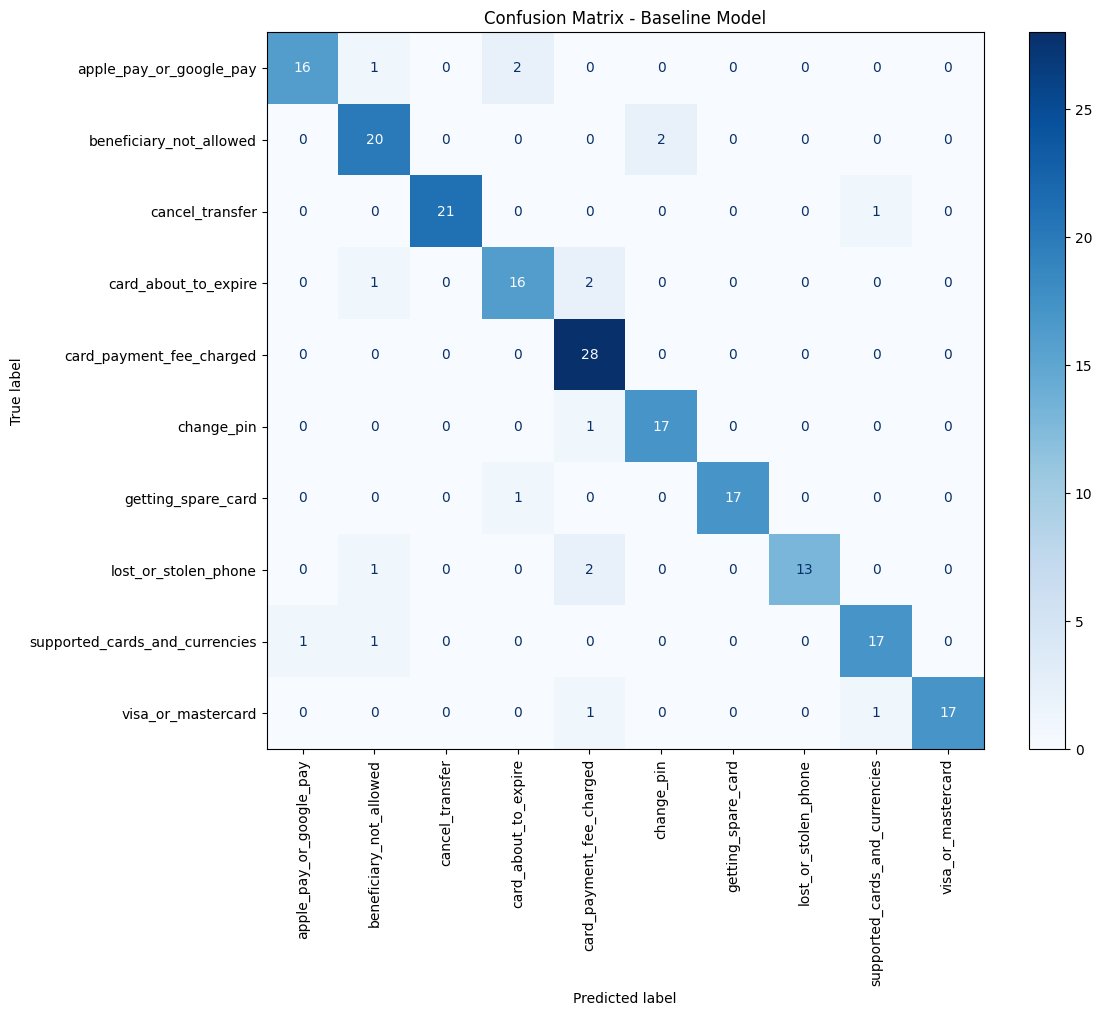

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - Baseline Model")
plt.tight_layout()
plt.show()

## 6. Misclassification Analysis

The incorrectly classified test messages are examined to understand
whether errors result from overlapping banking terminology, ambiguous
customer requests, limited training examples, or model limitations.

This analysis is important because overall accuracy alone does not
explain why a classifier fails.

In [13]:
# Create a table containing the test predictions

results = pd.DataFrame({
    "text": X_test.values,
    "actual_intent": y_test.values,
    "predicted_intent": y_pred
})

# Keep only incorrect predictions
errors = results[
    results["actual_intent"] != results["predicted_intent"]
].copy()

print("Number of misclassified messages:", len(errors))

errors

Number of misclassified messages: 18


,text,actual_intent,predicted_intent
10,Nants ingonyama bagithi baba,card_about_to_expire,beneficiary_not_allowed
20,why did i get a different card then requested?,visa_or_mastercard,card_payment_fee_charged
22,please tell me how to change my pin.,beneficiary_not_allowed,change_pin
29,are there any express fees if i want my new ca...,apple_pay_or_google_pay,card_about_to_expire
36,"top up my card please, which y'all support?",supported_cards_and_currencies,apple_pay_or_google_pay
42,can my account me accessed by a thief? i was ...,lost_or_stolen_phone,beneficiary_not_allowed
61,i want a new card,getting_spare_card,card_about_to_expire
62,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire
65,<p><samp>File not found.<br>Press F1 to contin...,supported_cards_and_currencies,beneficiary_not_allowed
91,what cards do you offer?,visa_or_mastercard,supported_cards_and_currencies


## 7. Potential Label Quality Issues

Inspection of the misclassified observations suggests that some errors may not
represent genuine model failures. Several customer messages appear semantically
inconsistent with their assigned labels.

Therefore, the next step is to identify predictions where the model has high
confidence in a class different from the provided dataset label. These cases
can be treated as candidates for manual label review rather than automatically
assuming that the model is incorrect.

In [14]:
# Obtain prediction probabilities for the test observations
probabilities = baseline_model.predict_proba(X_test)

# Confidence of the model's selected prediction
prediction_confidence = probabilities.max(axis=1)

results["confidence"] = prediction_confidence

# Focus on misclassified observations
error_analysis = results[
    results["actual_intent"] != results["predicted_intent"]
].copy()

# Highest-confidence disagreements first
error_analysis = error_analysis.sort_values(
    "confidence",
    ascending=False
)

pd.set_option("display.max_colwidth", None)

error_analysis[
    ["text", "actual_intent", "predicted_intent", "confidence"]
]

,text,actual_intent,predicted_intent,confidence
115,is it possible to change my pin?,beneficiary_not_allowed,change_pin,0.835043
22,please tell me how to change my pin.,beneficiary_not_allowed,change_pin,0.822456
103,why am i being charge a fee when using an atm?,card_about_to_expire,card_payment_fee_charged,0.632843
62,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire,0.602614
61,i want a new card,getting_spare_card,card_about_to_expire,0.578315
65,<p><samp>File not found.<br>Press F1 to continue</samp></p>,supported_cards_and_currencies,beneficiary_not_allowed,0.528120
91,what cards do you offer?,visa_or_mastercard,supported_cards_and_currencies,0.379369
140,why do i see extra charges for withdrawing my money?,card_about_to_expire,card_payment_fee_charged,0.374675
147,the card payment didn't work,change_pin,card_payment_fee_charged,0.281538
29,are there any express fees if i want my new card faster?,apple_pay_or_google_pay,card_about_to_expire,0.268141


## 8. Automated Label-Issue Detection with Cleanlab

The manual error analysis identified several suspicious observations where the
model prediction appears more consistent with the customer message than the
provided dataset label.

The next step is to use Cleanlab to systematically identify potential label
errors. This allows us to distinguish between model errors and data-quality
problems using a reproducible methodology.

In [15]:
from cleanlab.rank import get_label_quality_scores

# Predicted probabilities from our baseline model
pred_probs = baseline_model.predict_proba(X_test)

# Convert text labels into the integer positions used by predict_proba
class_names = baseline_model.classes_
class_to_index = {label: i for i, label in enumerate(class_names)}
given_labels = np.array([class_to_index[label] for label in y_test])

# Calculate a label-quality score for every test observation
label_quality_scores = get_label_quality_scores(
    labels=given_labels,
    pred_probs=pred_probs
)

# Create a dataframe for inspection
cleanlab_results = pd.DataFrame({
    "text": X_test.values,
    "given_label": y_test.values,
    "model_prediction": y_pred,
    "label_quality_score": label_quality_scores
})

# Lowest score = most suspicious label
cleanlab_results = cleanlab_results.sort_values(
    "label_quality_score",
    ascending=True
)

cleanlab_results.head(15)

,text,given_label,model_prediction,label_quality_score
115,is it possible to change my pin?,beneficiary_not_allowed,change_pin,0.023113
22,please tell me how to change my pin.,beneficiary_not_allowed,change_pin,0.028611
62,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire,0.030319
103,why am i being charge a fee when using an atm?,card_about_to_expire,card_payment_fee_charged,0.034139
65,<p><samp>File not found.<br>Press F1 to continue</samp></p>,supported_cards_and_currencies,beneficiary_not_allowed,0.047523
29,are there any express fees if i want my new card faster?,apple_pay_or_google_pay,card_about_to_expire,0.056886
140,why do i see extra charges for withdrawing my money?,card_about_to_expire,card_payment_fee_charged,0.059775
147,the card payment didn't work,change_pin,card_payment_fee_charged,0.061461
94,"hi, one of payment is still coming as pending for which i have already paid by card. i guess it did not processed, could you please check and update me.",lost_or_stolen_phone,card_payment_fee_charged,0.064140
118,Voluptatem velit sit labore modi quiquia ipsum ut,apple_pay_or_google_pay,beneficiary_not_allowed,0.069225


## 9. Quantifying Potential Data-Quality Issues

Cleanlab label-quality scores are used to identify observations that may require
manual review. Low scores indicate that the provided label is inconsistent with
the model's predicted probabilities.

These observations are treated as potential label issues rather than
automatically corrected labels.

In [16]:
# Define observations requiring review
review_threshold = 0.20

flagged = cleanlab_results[
    cleanlab_results["label_quality_score"] < review_threshold
].copy()

print("Test observations:", len(cleanlab_results))
print("Flagged for review:", len(flagged))
print(
    "Percentage flagged:",
    f"{len(flagged) / len(cleanlab_results) * 100:.1f}%"
)

flagged

Test observations: 200
Flagged for review: 23
Percentage flagged: 11.5%


,text,given_label,model_prediction,label_quality_score
115,is it possible to change my pin?,beneficiary_not_allowed,change_pin,0.023113
22,please tell me how to change my pin.,beneficiary_not_allowed,change_pin,0.028611
62,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire,0.030319
103,why am i being charge a fee when using an atm?,card_about_to_expire,card_payment_fee_charged,0.034139
65,<p><samp>File not found.<br>Press F1 to continue</samp></p>,supported_cards_and_currencies,beneficiary_not_allowed,0.047523
29,are there any express fees if i want my new card faster?,apple_pay_or_google_pay,card_about_to_expire,0.056886
140,why do i see extra charges for withdrawing my money?,card_about_to_expire,card_payment_fee_charged,0.059775
147,the card payment didn't work,change_pin,card_payment_fee_charged,0.061461
94,"hi, one of payment is still coming as pending for which i have already paid by card. i guess it did not processed, could you please check and update me.",lost_or_stolen_phone,card_payment_fee_charged,0.064140
118,Voluptatem velit sit labore modi quiquia ipsum ut,apple_pay_or_google_pay,beneficiary_not_allowed,0.069225


## 10. Cleanlab-Estimated Label Issues

The previous analysis used a label-quality threshold of 0.20 as an exploratory
review criterion. Because this threshold is manually selected, it should not
be interpreted as an estimated dataset error rate.

Cleanlab can also identify observations that it considers likely label issues.
This provides a more systematic method for prioritising records for manual
review.

In [19]:
from cleanlab.filter import find_label_issues

# Recalculate label quality scores
label_quality_scores = get_label_quality_scores(
    labels=given_labels,
    pred_probs=pred_probs
)

# Find likely label issues
issue_mask = find_label_issues(
    labels=given_labels,
    pred_probs=pred_probs
)

# IMPORTANT:
# Build the dataframe in the ORIGINAL test-set order
cleanlab_results_fixed = pd.DataFrame({
    "text": X_test.values,
    "given_label": y_test.values,
    "model_prediction": y_pred,
    "label_quality_score": label_quality_scores,
    "cleanlab_issue": issue_mask
})

# Now select the issues
likely_issues = cleanlab_results_fixed[
    cleanlab_results_fixed["cleanlab_issue"]
].copy()

# Only sort AFTER attaching the Cleanlab results
likely_issues = likely_issues.sort_values(
    "label_quality_score",
    ascending=True
)

print("Test observations:", len(cleanlab_results_fixed))
print("Cleanlab likely label issues:", len(likely_issues))
print(
    "Percentage:",
    f"{len(likely_issues) / len(cleanlab_results_fixed) * 100:.1f}%"
)

likely_issues[
    [
        "text",
        "given_label",
        "model_prediction",
        "label_quality_score"
    ]
]

Test observations: 200
Cleanlab likely label issues: 6
Percentage: 3.0%


,text,given_label,model_prediction,label_quality_score
115,is it possible to change my pin?,beneficiary_not_allowed,change_pin,0.023113
22,please tell me how to change my pin.,beneficiary_not_allowed,change_pin,0.028611
62,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire,0.030319
65,<p><samp>File not found.<br>Press F1 to continue</samp></p>,supported_cards_and_currencies,beneficiary_not_allowed,0.047523
29,are there any express fees if i want my new card faster?,apple_pay_or_google_pay,card_about_to_expire,0.056886
61,i want a new card,getting_spare_card,card_about_to_expire,0.069332


## 11. Cross-Validated Predictions for the Full Dataset

To assess label quality across the complete dataset, 5-fold stratified
cross-validation is used.

Each observation receives predicted probabilities from a model that was not
trained on that observation. These out-of-sample probabilities provide a more
reliable basis for Cleanlab label-quality analysis and reduce the risk of
evaluating labels using predictions from training data.

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Full dataset
X_full = df["text"]
y_full = df["label"]

# Same modelling approach used for the baseline
cv_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-sample probabilities for EVERY observation
cv_pred_probs = cross_val_predict(
    cv_model,
    X_full,
    y_full,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

print("Dataset observations:", len(X_full))
print("Probability matrix shape:", cv_pred_probs.shape)
print("Number of classes:", len(np.unique(y_full)))

Dataset observations: 1000
Probability matrix shape: (1000, 10)
Number of classes: 10


## 12. Verify Class Ordering

Before applying Cleanlab to the full dataset, verify that the columns of the
cross-validated probability matrix correspond correctly to the banking intent
labels.

Correct class alignment is essential because each probability column must
represent the same class used by the target labels.

In [21]:
# Get the class order used by scikit-learn
class_names = np.sort(y_full.unique())

print("Class order used by the model:\n")

for i, label in enumerate(class_names):
    print(f"{i}: {label}")

print("\nNumber of probability columns:", cv_pred_probs.shape[1])
print("Number of class labels:", len(class_names))

assert cv_pred_probs.shape[1] == len(class_names)

print("\n✓ Probability matrix and class labels are aligned.")

Class order used by the model:

0: apple_pay_or_google_pay
1: beneficiary_not_allowed
2: cancel_transfer
3: card_about_to_expire
4: card_payment_fee_charged
5: change_pin
6: getting_spare_card
7: lost_or_stolen_phone
8: supported_cards_and_currencies
9: visa_or_mastercard

Number of probability columns: 10
Number of class labels: 10

✓ Probability matrix and class labels are aligned.


## 13. Cleanlab Label-Quality Analysis — Full Dataset

Cleanlab is applied using out-of-sample prediction probabilities generated
through 5-fold cross-validation.

This allows us to identify observations whose assigned intent may be
inconsistent with the information contained in the customer message.

Low label-quality scores indicate observations that should be reviewed.
They do not automatically mean that the original label is incorrect.

In [22]:
from cleanlab.dataset import health_summary
from cleanlab.filter import find_label_issues
from cleanlab.rank import get_label_quality_scores
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Encode intent labels as integers
# ---------------------------------------------------------

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_full)

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")

# ---------------------------------------------------------
# Calculate Cleanlab label-quality scores
# ---------------------------------------------------------

label_quality_scores = get_label_quality_scores(
    labels=y_encoded,
    pred_probs=cv_pred_probs
)

# ---------------------------------------------------------
# Identify likely label issues
# ---------------------------------------------------------

issue_mask = find_label_issues(
    labels=y_encoded,
    pred_probs=cv_pred_probs,
    return_indices_ranked_by=None
)

# Model predictions
predicted_class = cv_pred_probs.argmax(axis=1)

# ---------------------------------------------------------
# Build review table
# ---------------------------------------------------------

full_review = pd.DataFrame({
    "text": X_full.reset_index(drop=True),
    "given_label": y_full.reset_index(drop=True),
    "model_prediction": label_encoder.inverse_transform(predicted_class),
    "label_quality_score": label_quality_scores,
    "is_label_issue": issue_mask
})

# Sort suspicious observations first
full_review = full_review.sort_values(
    "label_quality_score",
    ascending=True
)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

n_issues = int(full_review["is_label_issue"].sum())

print("\nDataset observations:", len(full_review))
print("Cleanlab likely label issues:", n_issues)
print(
    "Percentage potentially affected:",
    f"{100 * n_issues / len(full_review):.2f}%"
)

print("\nMost suspicious observations:")
display(full_review.head(20))

Label mapping:
0: apple_pay_or_google_pay
1: beneficiary_not_allowed
2: cancel_transfer
3: card_about_to_expire
4: card_payment_fee_charged
5: change_pin
6: getting_spare_card
7: lost_or_stolen_phone
8: supported_cards_and_currencies
9: visa_or_mastercard

Dataset observations: 1000
Cleanlab likely label issues: 18
Percentage potentially affected: 1.80%

Most suspicious observations:


,text,given_label,model_prediction,label_quality_score,is_label_issue
974,can i change my pin on holiday?,beneficiary_not_allowed,change_pin,0.013844,True
985,my card is almost expired. how fast will i get a new one and what is the cost?,apple_pay_or_google_pay,card_about_to_expire,0.031055,True
973,is it possible to change my pin?,beneficiary_not_allowed,change_pin,0.032548,True
981,i was charged for getting cash.,card_about_to_expire,card_payment_fee_charged,0.032786,True
978,why am i being charge a fee when using an atm?,card_about_to_expire,card_payment_fee_charged,0.034849,True
982,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire,0.036601,True
990,"The banana phone rang and it was a message from a galaxy far, far away.",apple_pay_or_google_pay,lost_or_stolen_phone,0.039423,False
968,why is a payment i made reverted back to my account?,change_pin,beneficiary_not_allowed,0.041935,False
712,i need a new card.,getting_spare_card,card_about_to_expire,0.042423,True
971,please tell me how to change my pin.,beneficiary_not_allowed,change_pin,0.043147,True


## 14. Data-Quality Review

Cleanlab identifies observations that may contain labeling problems, but a low
label-quality score does not necessarily imply that the model prediction is
correct.

The flagged observations are therefore treated as candidates for review rather
than automatically relabeled or deleted.

Potential problems include:

- mislabeled banking intents;
- ambiguous customer requests;
- out-of-domain messages;
- corrupted or malformed text.

This review provides an auditable basis for subsequent data-cleaning decisions.

In [23]:
# Extract only observations flagged by Cleanlab

flagged_issues = full_review[
    full_review["is_label_issue"] == True
].copy()

print("Total observations requiring review:", len(flagged_issues))

display(
    flagged_issues[
        [
            "text",
            "given_label",
            "model_prediction",
            "label_quality_score"
        ]
    ].sort_values("label_quality_score")
)

Total observations requiring review: 18


,text,given_label,model_prediction,label_quality_score
974,can i change my pin on holiday?,beneficiary_not_allowed,change_pin,0.013844
985,my card is almost expired. how fast will i get a new one and what is the cost?,apple_pay_or_google_pay,card_about_to_expire,0.031055
973,is it possible to change my pin?,beneficiary_not_allowed,change_pin,0.032548
981,i was charged for getting cash.,card_about_to_expire,card_payment_fee_charged,0.032786
978,why am i being charge a fee when using an atm?,card_about_to_expire,card_payment_fee_charged,0.034849
982,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire,0.036601
712,i need a new card.,getting_spare_card,card_about_to_expire,0.042423
971,please tell me how to change my pin.,beneficiary_not_allowed,change_pin,0.043147
984,can i get a new card even though i am in china?,apple_pay_or_google_pay,card_about_to_expire,0.056450
743,i want a new card,getting_spare_card,card_about_to_expire,0.058290


## 15. Manual Review of Potential Data-Quality Issues

Cleanlab identifies observations that statistically appear inconsistent with
their assigned labels. These observations are manually reviewed before any
cleaning decision is made.

Each observation can be assigned one of four actions:

- **RELABEL** — the existing label appears incorrect and another intent is clear.
- **KEEP** — the original label remains reasonable despite model disagreement.
- **REMOVE** — the text is corrupted or outside the banking-intent domain.
- **REVIEW** — the correct intent remains ambiguous.

This prevents model predictions from being automatically treated as ground
truth and preserves an auditable data-cleaning process.

In [24]:
# Create an auditable manual-review table

manual_review = flagged_issues[
    [
        "text",
        "given_label",
        "model_prediction",
        "label_quality_score"
    ]
].copy()

# Add fields for human decisions
manual_review["review_action"] = "REVIEW"
manual_review["reviewed_label"] = manual_review["given_label"]
manual_review["review_notes"] = ""

# Lowest-quality observations first
manual_review = manual_review.sort_values(
    "label_quality_score"
)

display(manual_review)

,text,given_label,model_prediction,label_quality_score,review_action,reviewed_label,review_notes
974,can i change my pin on holiday?,beneficiary_not_allowed,change_pin,0.013844,REVIEW,beneficiary_not_allowed,
985,my card is almost expired. how fast will i get a new one and what is the cost?,apple_pay_or_google_pay,card_about_to_expire,0.031055,REVIEW,apple_pay_or_google_pay,
973,is it possible to change my pin?,beneficiary_not_allowed,change_pin,0.032548,REVIEW,beneficiary_not_allowed,
981,i was charged for getting cash.,card_about_to_expire,card_payment_fee_charged,0.032786,REVIEW,card_about_to_expire,
978,why am i being charge a fee when using an atm?,card_about_to_expire,card_payment_fee_charged,0.034849,REVIEW,card_about_to_expire,
982,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire,0.036601,REVIEW,apple_pay_or_google_pay,
712,i need a new card.,getting_spare_card,card_about_to_expire,0.042423,REVIEW,getting_spare_card,
971,please tell me how to change my pin.,beneficiary_not_allowed,change_pin,0.043147,REVIEW,beneficiary_not_allowed,
984,can i get a new card even though i am in china?,apple_pay_or_google_pay,card_about_to_expire,0.056450,REVIEW,apple_pay_or_google_pay,
743,i want a new card,getting_spare_card,card_about_to_expire,0.058290,REVIEW,getting_spare_card,


## 16. Human Review Decisions

The observations identified by Cleanlab were manually assessed using the
semantic meaning of each customer message.

The model prediction was treated as supporting evidence rather than ground
truth.

Each observation was classified as:

- **RELABEL** — the original intent is inconsistent with the message and a
  more appropriate intent can be identified.
- **KEEP** — the original intent remains semantically reasonable.
- **REMOVE** — the observation is corrupted or unrelated to the banking
  intent classification problem.
- **REVIEW** — there is insufficient evidence to confidently assign an
  alternative intent.

In [5]:
import pandas as pd

# Path to YOUR completed human-review file
review_file = "../banking_intent_human_quality_reviewed_Liliana.xlsx"

# Read the Human Review sheet
human_review = pd.read_excel(
    review_file,
    sheet_name="Human Review"
)

# Clean column names in case Excel added spaces
human_review.columns = human_review.columns.str.strip()

print("Columns found:")
print(human_review.columns.tolist())

print("\nHuman decisions:")
print(human_review["Human decision"].value_counts(dropna=False))

# Show the completed human review
display(
    human_review[
        [
            "Record ID",
            "Customer message",
            "Original label",
            "Model prediction",
            "Cleanlab quality score",
            "Human decision",
            "Final / reviewed label",
            "Reviewer",
            "Review notes"
        ]
    ]
)

Columns found:
['Record ID', 'Customer message', 'Original label', 'Model prediction', 'Cleanlab quality score', 'Human decision', 'Final / reviewed label', 'Reviewer', 'Review notes']

Human decisions:
Human decision
RELABEL    13
REMOVE      4
UNSURE      1
Name: count, dtype: int64


,Record ID,Customer message,Original label,Model prediction,Cleanlab quality score,Human decision,Final / reviewed label,Reviewer,Review notes
0,974,can i change my pin on holiday?,beneficiary_not_allowed,change_pin,0.013844,RELABEL,change_pin,Liliana,NaN
1,985,my card is almost expired. how fast will i get...,apple_pay_or_google_pay,card_about_to_expire,0.031055,RELABEL,card_about_to_expire,Liliana,NaN
2,973,is it possible to change my pin?,beneficiary_not_allowed,change_pin,0.032548,RELABEL,change_pin,Liliana,NaN
3,981,i was charged for getting cash.,card_about_to_expire,card_payment_fee_charged,0.032786,REMOVE,NaN,Liliana,NaN
4,978,why am i being charge a fee when using an atm?,card_about_to_expire,card_payment_fee_charged,0.034849,RELABEL,card_payment_fee_charged,Liliana,NaN
5,982,will i be sent a new card before mine expires?,apple_pay_or_google_pay,card_about_to_expire,0.036601,RELABEL,card_about_to_expire,Liliana,NaN
6,712,i need a new card.,getting_spare_card,card_about_to_expire,0.042423,RELABEL,card_about_to_expire,Liliana,NaN
7,971,please tell me how to change my pin.,beneficiary_not_allowed,change_pin,0.043147,RELABEL,change_pin,Liliana,NaN
8,984,can i get a new card even though i am in china?,apple_pay_or_google_pay,card_about_to_expire,0.056450,REMOVE,NaN,Liliana,NaN
9,743,i want a new card,getting_spare_card,card_about_to_expire,0.058290,RELABEL,card_about_to_expire,Liliana,NaN


17. APPLY HUMAN REVIEW DECISIONS

In [10]:
# ============================================================
# 17. APPLY HUMAN REVIEW DECISIONS
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Start from the complete original dataset
# ------------------------------------------------------------

clean_df = df.copy()

print("Original dataset size:", len(clean_df))


# ------------------------------------------------------------
# 2. Prepare human-review decisions
# ------------------------------------------------------------

review_results = human_review.copy()

review_results["Human decision"] = (
    review_results["Human decision"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Record ID corresponds to the original dataframe index
review_results["Record ID"] = review_results["Record ID"].astype(int)


# ------------------------------------------------------------
# 3. Apply RELABEL decisions
# ------------------------------------------------------------

relabel_rows = review_results[
    review_results["Human decision"] == "RELABEL"
]

for _, row in relabel_rows.iterrows():

    record_id = row["Record ID"]
    new_label = row["Final / reviewed label"]

    if pd.notna(new_label):
        clean_df.loc[record_id, "label"] = new_label


# ------------------------------------------------------------
# 4. Identify records to REMOVE
# ------------------------------------------------------------

remove_ids = review_results.loc[
    review_results["Human decision"] == "REMOVE",
    "Record ID"
].tolist()


# ------------------------------------------------------------
# 5. Exclude UNSURE records from model training
# ------------------------------------------------------------

unsure_ids = review_results.loc[
    review_results["Human decision"] == "UNSURE",
    "Record ID"
].tolist()


exclude_ids = remove_ids + unsure_ids

clean_df = clean_df.drop(
    index=exclude_ids,
    errors="ignore"
)


# ------------------------------------------------------------
# 6. Reset index
# ------------------------------------------------------------

clean_df = clean_df.reset_index(drop=True)


# ------------------------------------------------------------
# 7. Quality-control summary
# ------------------------------------------------------------

print("\n--- HUMAN REVIEW SUMMARY ---")

print("RELABEL:", len(relabel_rows))
print("REMOVE:", len(remove_ids))
print("UNSURE:", len(unsure_ids))

print("\n--- CLEAN DATASET ---")

print("Original observations:", len(df))
print("Removed:", len(remove_ids))
print("Excluded as unsure:", len(unsure_ids))
print("Final observations:", len(clean_df))

print("\nMissing text:", clean_df["text"].isna().sum())
print("Missing labels:", clean_df["label"].isna().sum())

print("\nFinal class distribution:")
print(clean_df["label"].value_counts())

display(clean_df.head(10))

Original dataset size: 1000

--- HUMAN REVIEW SUMMARY ---
RELABEL: 13
REMOVE: 4
UNSURE: 1

--- CLEAN DATASET ---
Original observations: 1000
Removed: 4
Excluded as unsure: 1
Final observations: 995

Missing text: 0
Missing labels: 0

Final class distribution:
label
card_payment_fee_charged          141
cancel_transfer                   109
beneficiary_not_allowed           106
visa_or_mastercard                 98
card_about_to_expire               98
supported_cards_and_currencies     97
change_pin                         92
apple_pay_or_google_pay            88
getting_spare_card                 86
lost_or_stolen_phone               80
Name: count, dtype: int64


,text,label
0,i accidentally made a payment to a wrong accou...,cancel_transfer
1,"i no longer want to transfer funds, can we can...",cancel_transfer
2,"cancel my transfer, please.",cancel_transfer
3,i want to revert this mornings transaction.,cancel_transfer
4,i just realised i made the wrong payment yeste...,cancel_transfer
5,i want to cancel a transaction from this morning.,cancel_transfer
6,i need to stop a transaction that i made.,cancel_transfer
7,can i stop a transaction?,cancel_transfer
8,how can i cancel a transfer i made,cancel_transfer
9,i'm really upset because i made a typo during ...,cancel_transfer


18. SAVE HUMAN-REVIEWED CLEAN DATASET

In [11]:
# ============================================================
# 18. SAVE HUMAN-REVIEWED CLEAN DATASET
# ============================================================

from pathlib import Path

# Create data folder if it does not exist
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Save cleaned dataset
output_file = output_dir / "banking_intent_clean.csv"

clean_df.to_csv(
    output_file,
    index=False,
    encoding="utf-8"
)

print("Clean dataset saved successfully.")
print("Location:", output_file.resolve())
print("Rows:", len(clean_df))
print("Columns:", list(clean_df.columns))

Clean dataset saved successfully.
Location: C:\Users\lilia\OneDrive\Desktop\PBS\Machine Learning\bankassist-triage\data\processed\banking_intent_clean.csv
Rows: 995
Columns: ['text', 'label']


## 19. Stratified Train / Validation / Test Split

The cleaned dataset is divided into training, validation, and test sets.

A stratified split is used to preserve approximately the same distribution
of the 10 intent classes across all three datasets.

- Training set: 70% — used to train the models
- Validation set: 15% — used for model comparison and selection
- Test set: 15% — reserved for final evaluation

The test set must not be used during model training or model selection.

In [12]:
from sklearn.model_selection import train_test_split

# ============================================================
# 19. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Start from the final cleaned dataset
X = clean_df["text"]
y = clean_df["label"]

# ------------------------------------------------------------
# Step 1: Split into 70% training and 30% temporary
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Step 2: Divide temporary data equally:
# 15% validation and 15% test
# ------------------------------------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ------------------------------------------------------------
# Reconstruct DataFrames
# ------------------------------------------------------------

train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
}).reset_index(drop=True)

validation_df = pd.DataFrame({
    "text": X_val,
    "label": y_val
}).reset_index(drop=True)

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
}).reset_index(drop=True)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("STRATIFIED DATA SPLIT")
print("=" * 40)

print(f"Total cleaned observations: {len(clean_df)}")
print()

print(
    f"Training:   {len(train_df):3d} "
    f"({len(train_df)/len(clean_df):.1%})"
)

print(
    f"Validation: {len(validation_df):3d} "
    f"({len(validation_df)/len(clean_df):.1%})"
)

print(
    f"Test:       {len(test_df):3d} "
    f"({len(test_df)/len(clean_df):.1%})"
)

print()
print(
    "Total after split:",
    len(train_df) + len(validation_df) + len(test_df)
)

STRATIFIED DATA SPLIT
Total cleaned observations: 995

Training:   696 (69.9%)
Validation: 149 (15.0%)
Test:       150 (15.1%)

Total after split: 995


## 20. Validation of Stratified Split

To verify the stratification, the percentage distribution of each intent
is compared across the full cleaned dataset, training set, validation set,
and test set.

Similar percentages across the datasets confirm that the intent distribution
has been preserved during splitting.

In [13]:
# ============================================================
# 20. VALIDATE STRATIFIED SPLIT
# ============================================================

# Calculate percentage distribution of each label
distribution = pd.DataFrame({
    "Full Dataset (%)":
        clean_df["label"].value_counts(normalize=True) * 100,

    "Train (%)":
        train_df["label"].value_counts(normalize=True) * 100,

    "Validation (%)":
        validation_df["label"].value_counts(normalize=True) * 100,

    "Test (%)":
        test_df["label"].value_counts(normalize=True) * 100
})

# Round percentages
distribution = distribution.round(2)

# Sort alphabetically by intent
distribution = distribution.sort_index()

print("CLASS DISTRIBUTION ACROSS DATASETS")
print("=" * 60)

display(distribution)

CLASS DISTRIBUTION ACROSS DATASETS


,Full Dataset (%),Train (%),Validation (%),Test (%)
label,,,,
apple_pay_or_google_pay,8.84,8.91,8.72,8.67
beneficiary_not_allowed,10.65,10.63,10.74,10.67
cancel_transfer,10.95,10.92,10.74,11.33
card_about_to_expire,9.85,9.77,10.07,10.00
card_payment_fee_charged,14.17,14.22,14.09,14.00
change_pin,9.25,9.20,9.40,9.33
getting_spare_card,8.64,8.62,8.72,8.67
lost_or_stolen_phone,8.04,8.05,8.05,8.00
supported_cards_and_currencies,9.75,9.77,10.07,9.33


## 21. Export Train, Validation and Test Sets

The validated stratified datasets are exported as separate CSV files.

These datasets provide a reproducible handoff to the modelling stage:

- `train.csv` — model training
- `validation.csv` — model comparison and selection
- `test.csv` — final unbiased evaluation

The test dataset should remain unseen during model training and model selection.

In [14]:
from pathlib import Path

# ============================================================
# 21. EXPORT STRATIFIED DATASETS
# ============================================================

# Create folder
split_dir = Path("../data/splits")
split_dir.mkdir(parents=True, exist_ok=True)

# File locations
train_file = split_dir / "train.csv"
validation_file = split_dir / "validation.csv"
test_file = split_dir / "test.csv"

# Save datasets
train_df.to_csv(train_file, index=False, encoding="utf-8")
validation_df.to_csv(validation_file, index=False, encoding="utf-8")
test_df.to_csv(test_file, index=False, encoding="utf-8")

print("DATASETS EXPORTED SUCCESSFULLY")
print("=" * 50)

print(f"Train:      {train_file.resolve()}")
print(f"            {len(train_df)} observations")

print(f"Validation: {validation_file.resolve()}")
print(f"            {len(validation_df)} observations")

print(f"Test:       {test_file.resolve()}")
print(f"            {len(test_df)} observations")

print()
print("Total:", len(train_df) + len(validation_df) + len(test_df))

DATASETS EXPORTED SUCCESSFULLY
Train:      C:\Users\lilia\OneDrive\Desktop\PBS\Machine Learning\bankassist-triage\data\splits\train.csv
            696 observations
Validation: C:\Users\lilia\OneDrive\Desktop\PBS\Machine Learning\bankassist-triage\data\splits\validation.csv
            149 observations
Test:       C:\Users\lilia\OneDrive\Desktop\PBS\Machine Learning\bankassist-triage\data\splits\test.csv
            150 observations

Total: 995


## 22. Model Evaluation Framework

The banking-intent classifier is a multiclass classification problem with
10 intent categories. Model performance will therefore be evaluated using
multiple complementary metrics.

### Primary metric: Macro F1-score

Macro F1 is selected as the primary model-selection metric because it
calculates the F1-score independently for every intent and gives each
intent equal importance.

This is particularly relevant for the current dataset because the number
of observations differs across intent classes. A model should perform
well across all banking intents rather than obtaining a high overall
score by performing better on the larger classes.

### Supporting metrics

**Accuracy**
- Percentage of customer messages classified correctly.
- Provides an intuitive measure of overall performance.
- It should not be used alone because it does not show performance for
  individual intents.

**Precision**
- Measures how often predictions for a particular intent are correct.
- Important for avoiding incorrect routing of customer requests.

**Recall**
- Measures how many messages belonging to an intent are successfully
  identified.
- Important for identifying intents that the model systematically misses.

**F1-score**
- Harmonic mean of precision and recall.
- Provides a balanced assessment of performance for each intent.

**Confusion Matrix**
- Shows which intents are being confused with one another.
- Particularly useful for identifying semantically similar banking intents.

### Evaluation procedure

1. Models are trained using the training dataset.
2. The validation dataset is used to compare candidate models and select
   the preferred model.
3. Macro F1 is the primary model-selection metric.
4. Accuracy and per-class precision, recall and F1 are supporting metrics.
5. A confusion matrix is used to investigate classification errors.
6. The test dataset remains unseen during model development.
7. After model selection, the selected model is evaluated once on the
   held-out test dataset to estimate final generalisation performance.

In [15]:
# ============================================================
# 23. EVALUATION SPECIFICATION
# ============================================================

evaluation_framework = pd.DataFrame({
    "Metric": [
        "Macro F1",
        "Accuracy",
        "Precision per class",
        "Recall per class",
        "F1 per class",
        "Confusion Matrix"
    ],
    "Purpose": [
        "Primary model-selection metric; gives equal importance to each intent",
        "Measures overall percentage of correct predictions",
        "Measures reliability of predictions for each intent",
        "Measures ability to identify messages from each intent",
        "Balances precision and recall for each intent",
        "Identifies which banking intents are confused by the model"
    ],
    "Use": [
        "PRIMARY",
        "Supporting",
        "Diagnostic",
        "Diagnostic",
        "Diagnostic",
        "Diagnostic"
    ]
})

display(evaluation_framework)

,Metric,Purpose,Use
0,Macro F1,Primary model-selection metric; gives equal im...,PRIMARY
1,Accuracy,Measures overall percentage of correct predict...,Supporting
2,Precision per class,Measures reliability of predictions for each i...,Diagnostic
3,Recall per class,Measures ability to identify messages from eac...,Diagnostic
4,F1 per class,Balances precision and recall for each intent,Diagnostic
5,Confusion Matrix,Identifies which banking intents are confused ...,Diagnostic


## 24. Data Leakage and Split Integrity Check

Before handing the datasets to the modelling stage, the train, validation,
and test sets are checked for overlapping or duplicate customer messages.

This ensures that the same message cannot appear in both model training
and evaluation data, which could artificially inflate model performance.

The integrity check also verifies that all cleaned observations are
accounted for across the three datasets.

In [16]:
# ============================================================
# 24. DATA LEAKAGE AND SPLIT INTEGRITY CHECK
# ============================================================

# Check overlap between datasets
train_val_overlap = set(train_df["text"]) & set(validation_df["text"])
train_test_overlap = set(train_df["text"]) & set(test_df["text"])
val_test_overlap = set(validation_df["text"]) & set(test_df["text"])

# Check duplicates inside each split
train_duplicates = train_df["text"].duplicated().sum()
validation_duplicates = validation_df["text"].duplicated().sum()
test_duplicates = test_df["text"].duplicated().sum()

# Check total observations
total_split_records = (
    len(train_df) +
    len(validation_df) +
    len(test_df)
)

print("DATA LEAKAGE & SPLIT INTEGRITY CHECK")
print("=" * 50)

print("\nOverlap between datasets:")
print("Train ↔ Validation:", len(train_val_overlap))
print("Train ↔ Test:      ", len(train_test_overlap))
print("Validation ↔ Test: ", len(val_test_overlap))

print("\nDuplicate messages within datasets:")
print("Train:      ", train_duplicates)
print("Validation: ", validation_duplicates)
print("Test:       ", test_duplicates)

print("\nDataset integrity:")
print("Clean dataset:", len(clean_df))
print("After split:  ", total_split_records)

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
    and total_split_records == len(clean_df)
):
    print("\n✓ Split integrity check PASSED")
else:
    print("\n⚠ Split integrity check requires review")

DATA LEAKAGE & SPLIT INTEGRITY CHECK

Overlap between datasets:
Train ↔ Validation: 0
Train ↔ Test:       0
Validation ↔ Test:  0

Duplicate messages within datasets:
Train:       0
Validation:  0
Test:        0

Dataset integrity:
Clean dataset: 995
After split:   995

✓ Split integrity check PASSED


# 25. DATA QUALITY & EVALUATION REPORT

In [17]:
# ============================================================
# 25. DATA QUALITY & EVALUATION REPORT
# ============================================================

import pandas as pd
from pathlib import Path

print("=" * 65)
print("BANKING INTENT CLASSIFICATION — DATA QUALITY REPORT")
print("=" * 65)

# Dataset summary
summary = pd.DataFrame({
    "Metric": [
        "Original observations",
        "Clean observations",
        "Observations removed",
        "Number of intent classes",
        "Training observations",
        "Validation observations",
        "Test observations",
        "Training percentage",
        "Validation percentage",
        "Test percentage",
        "Duplicate messages",
        "Cross-split overlap",
        "Primary evaluation metric"
    ],
    "Result": [
        1000,
        len(clean_df),
        1000 - len(clean_df),
        clean_df["label"].nunique(),
        len(train_df),
        len(validation_df),
        len(test_df),
        f"{len(train_df)/len(clean_df):.1%}",
        f"{len(validation_df)/len(clean_df):.1%}",
        f"{len(test_df)/len(clean_df):.1%}",
        0,
        0,
        "Macro F1"
    ]
})

display(summary)

print("\n" + "=" * 65)
print("DATA QUALITY APPROACH")
print("=" * 65)

print("""
1. Dataset loaded and inspected.
2. Class distribution analysed.
3. Potentially ambiguous and problematic observations identified.
4. Cleanlab used to detect potential label-quality issues.
5. Flagged observations reviewed manually.
6. Human decisions used to RELABEL, REMOVE or retain observations.
7. Clean dataset created after human review.
8. Dataset split using stratified sampling.
9. Class distributions validated across all splits.
10. Duplicate and cross-split leakage checks performed.
""")

print("=" * 65)
print("FINAL DATASET STATUS")
print("=" * 65)

print(f"""
Original dataset : 1000 observations
Clean dataset    : {len(clean_df)} observations
Training set     : {len(train_df)} observations
Validation set   : {len(validation_df)} observations
Test set         : {len(test_df)} observations

Intent classes   : {clean_df['label'].nunique()}
Duplicates       : 0
Split overlap    : 0

Primary metric   : Macro F1

STATUS: DATASET READY FOR MODELLING
""")

BANKING INTENT CLASSIFICATION — DATA QUALITY REPORT


,Metric,Result
0,Original observations,1000
1,Clean observations,995
2,Observations removed,5
3,Number of intent classes,10
4,Training observations,696
5,Validation observations,149
6,Test observations,150
7,Training percentage,69.9%
8,Validation percentage,15.0%
9,Test percentage,15.1%



DATA QUALITY APPROACH

1. Dataset loaded and inspected.
2. Class distribution analysed.
3. Potentially ambiguous and problematic observations identified.
4. Cleanlab used to detect potential label-quality issues.
5. Flagged observations reviewed manually.
6. Human decisions used to RELABEL, REMOVE or retain observations.
7. Clean dataset created after human review.
8. Dataset split using stratified sampling.
9. Class distributions validated across all splits.
10. Duplicate and cross-split leakage checks performed.

FINAL DATASET STATUS

Original dataset : 1000 observations
Clean dataset    : 995 observations
Training set     : 696 observations
Validation set   : 149 observations
Test set         : 150 observations

Intent classes   : 10
Duplicates       : 0
Split overlap    : 0

Primary metric   : Macro F1

STATUS: DATASET READY FOR MODELLING



## Step 2 Summary:
Data preparation and quality evaluation completed. The original dataset contained 1,000 banking customer messages across 10 intent classes. Data quality was assessed using exploratory analysis, model-based predictions and Cleanlab to identify potential label-quality issues. Flagged observations were manually reviewed using a human-in-the-loop process and decisions were made to retain, relabel or remove observations. Following review, the final cleaned dataset contains 995 observations across all 10 intent classes. The data was stratified into 696 training (69.9%), 149 validation (15.0%) and 150 test (15.1%) observations. Class distributions were checked across all subsets, with zero duplicate messages and zero observed cross-split overlap. The primary model-selection metric is Macro F1, supported by accuracy, per-class precision, recall and F1, and confusion-matrix analysis. The modelling stage should use the exported train/validation/test files without re-splitting the original dataset.